In [58]:
from itertools import accumulate
from random import random, sample, seed
from collections.abc import Sequence
from icecream import ic
from matplotlib import pyplot as plt

In [59]:
N = 100
seed(42)

In [60]:
OBJECTS = {n for n in range(N)}
SETS = tuple(frozenset(sample(range(N), k=s+1)) for s in range(N))
COSTS = tuple(10*random()+(s*random())**2 for s in range(N))

# Solution: array of bools

In [61]:
def fitness_aob(solution: Sequence[bool]) -> float:
    weight = sum(COSTS[n] for n in range(N) if solution[n])
    check = frozenset().union(*(SETS[n] for n in range(N) if solution[n]))
    # removed the assert in order to allow partial solutions
    #assert check == frozenset(range(N))
    if check != frozenset(range(N)):
        # penalize incomplete solutions
        weight += 1000 * (N - len(check))
    return -weight

In [62]:
# initial professor sol
# sol = tuple(sample([True, False], k=N, counts=(N,N)))

# list solution (easier to modify)
sol = list(sample([True, False], k=N, counts=(N,N)))

ic(sol)

fitness_aob(sol)

ic| sol: [True,
          True,
          False,
          False,
          True,
          True,
          False,
          False,
          True,
          False,
          True,
          True,
          True,
          True,
          True,
          False,
          False,
          False,
          False,
          False,
          True,
          False,
          True,
          True,
          True,
          False,
          False,
          False,
          False,
          True,
          True,
          False,
          False,
          True,
          False,
          False,
          False,
          False,
          True,
          False,
          True,
          False,
          False,
          False,
          True,
          True,
          True,
          True,
          True,
          True,
          False,
          True,
          False,
          False,
          False,
          True,
          True,
          True,
          False,
          True,
          

-45970.974980840256

# Solution: set of sets

In [63]:
XCOSTS = {SETS[i]: COSTS[i] for i in range(N)}

In [64]:
def fitness_sos(solution: set[frozenset]) -> float:
    weight = sum(XCOSTS[s] for s in solution)
    check = frozenset().union(*solution)
    # removed the assert in order to allow partial solutions
    # assert check == frozenset(range(N))
    if check != frozenset(range(N)):
        # penalize incomplete solutions
        weight += 1000 * (N - len(check))
    return -weight

In [65]:
solution = set(sample(SETS, k=5))

ic(solution)

fitness_sos(solution)

ic| solution: 

{frozenset({81}),
               frozenset({0,
                          1,
                          2,
                          3,
                          4,
                          5,
                          6,
                          7,
                          9,
                          10,
                          11,
                          12,
                          13,
                          14,
                          15,
                          16,
                          17,
                          18,
                          19,
                          20,
                          21,
                          22,
                          23,
                          24,
                          25,
                          26,
                          27,
                          28,
                          29,
                          30,
                          31,
                          33,
                          34,
 

-3453.527351988569

In [66]:
def evaluate(solution):
    return sum(COSTS[s] for s in solution)

# Bool solution: implementation

In [67]:
# Simple tweak
# Randomly chooses a set to flip
# Amount of flips is randomized as well, with the average being 4 flips
def tweak(solution):
    while random() < 0.75:
        index = sample(range(N), k=1)[0]
        solution[index] = not solution[index]
    return solution

# old tweak (continue modifying until solution is valid)
# made because of the original assert in the fitness function
def old_tweak(solution: Sequence[bool]) -> Sequence[bool]:
    # Switch an element
    index = sample(range(N), k=1)[0]
    solution[index] = not solution[index]
    check = frozenset.union(*(SETS[n] for n in range(N) if solution[n]))
    while check != frozenset(range(N)):
        index = sample(range(N), k=1)[0]
        solution[index] = not solution[index]
        check = frozenset.union(*(SETS[n] for n in range(N) if solution[n]))
    return solution

def validate(solution: Sequence[bool]) -> bool:
    check = frozenset().union(*(SETS[n] for n in range(N) if solution[n]))
    return check == frozenset(range(N))

history = [fitness_aob(sol)]  # initial solution evaluation
no_improvements = 0
sol = list(sample([True, False], k=N, counts=(N,N)))
best_sol = sol.copy()

MAX_NO_IMPROVEMENTS = 200
# standard hill climbing
# 2.000 steps, with a restart if 100 steps yield no improvements
for _ in range(2000):
    new_sol = tweak(sol.copy())
    new_fitness = fitness_aob(new_sol)
    history.append(new_fitness)
    if new_fitness > fitness_aob(sol):
        # if new solution is better than the best
        if new_fitness > fitness_aob(best_sol) and validate(new_sol):
            best_sol = new_sol.copy()
        sol = new_sol.copy()
        no_improvements = 0
    else:
        no_improvements += 1
        # Restart from a random point
    if no_improvements >= MAX_NO_IMPROVEMENTS:
        sol = list(sample([True, False], k=N, counts=(N,N)))
        no_improvements = 0

# Note about results: The restarts prove useless in this case,
# but I will keep them as an example on how to use them.

ic(fitness_aob(best_sol), best_sol)

ic| fitness_aob(best_sol): -13.27163515105562
    best_sol: [False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
               False,
        

(-13.27163515105562,
 [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  True])

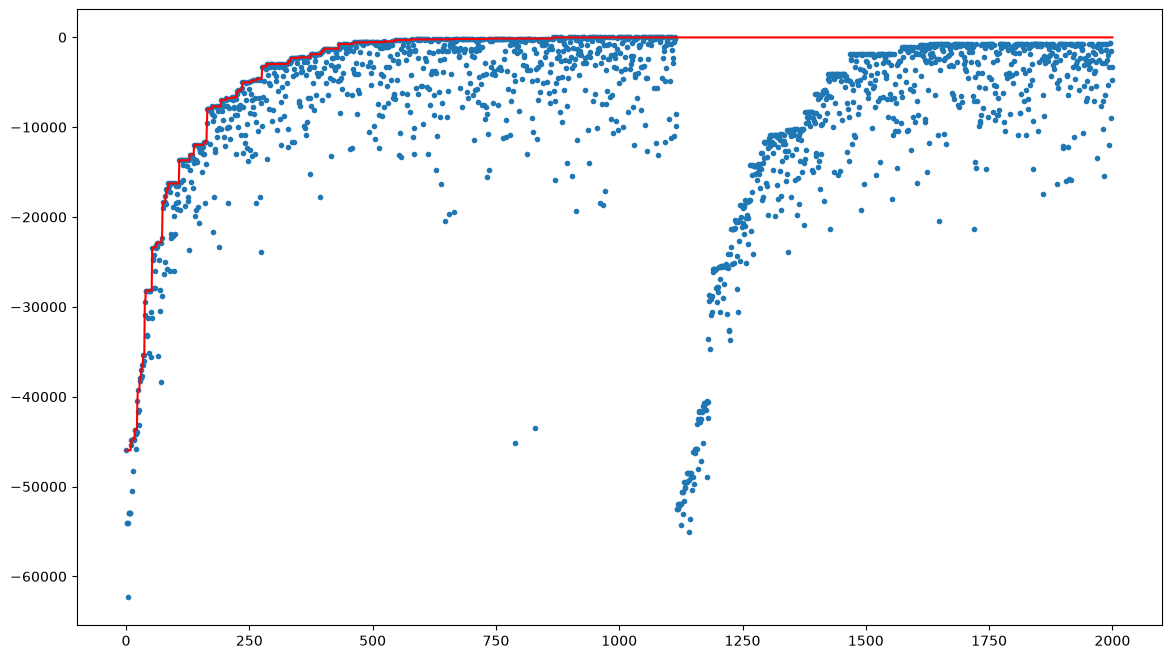

In [68]:
plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history)),
    list(accumulate(history, max)),
    color="red",
)
_ = plt.scatter(range(len(history)), history, marker=".")

# Set solution: implementation

In [69]:
def set_tweak(solution: set[frozenset]) -> set[frozenset]:
    while random() < 0.75:
        index = sample(range(N), k=1)[0]
        s = SETS[index]
        if s in solution:
            solution.remove(s)
        else:
            solution.add(s)
    return solution

def valid_solution(solution: set[frozenset]) -> bool:
    check = frozenset().union(*solution)
    return check == frozenset(range(N))

set_history = [fitness_sos(solution)]
# Random best solution
best_solution = set(sample(SETS, k=5))

# 10 restarts, 400 steps each
# very inefficient, it is mostly an example for set resolution
for _ in range(10):
    solution = set(sample(SETS, k=5))
    if fitness_sos(solution) > fitness_sos(best_solution) and valid_solution(solution):
        best_solution = solution.copy()
    set_history.append(fitness_sos(solution))
    # The inside loop only modifies the local solution
    for _ in range(400):
        candidate = set_tweak(solution.copy())
        fitness = fitness_sos(candidate)
        set_history.append(fitness)
        if fitness > fitness_sos(solution) and valid_solution(candidate):
            solution = candidate.copy()
    # Update the best solution if the local solution is better
    if fitness_sos(solution) > fitness_sos(best_solution) and valid_solution(solution):
        best_solution = solution.copy()

ic(fitness_sos(best_solution), best_solution)


ic| fitness_sos(best_solution): -46.08732447128921
    best_solution: {frozenset({0,
                               13,
                               19,
                               20,
                               22,
                               25,
                               38,
                               41,
                               47,
                               62,
                               64,
                               67,
                               69,
                               76,
                               77,
                               80,
                               81,
                               97,
                               99}),
                    frozenset({64, 3, 71, 77, 83, 25, 91}),
                    frozenset({0,
                               1,
                               2,
                               3,
                               4,
                               5,
                   

(-46.08732447128921,
 {frozenset({0,
             13,
             19,
             20,
             22,
             25,
             38,
             41,
             47,
             62,
             64,
             67,
             69,
             76,
             77,
             80,
             81,
             97,
             99}),
  frozenset({3, 25, 64, 71, 77, 83, 91}),
  frozenset({0,
             1,
             2,
             3,
             4,
             5,
             6,
             7,
             8,
             9,
             10,
             11,
             12,
             13,
             14,
             15,
             16,
             17,
             18,
             19,
             20,
             21,
             22,
             23,
             24,
             25,
             26,
             27,
             28,
             29,
             30,
             31,
             32,
             33,
             34,
             35,
           

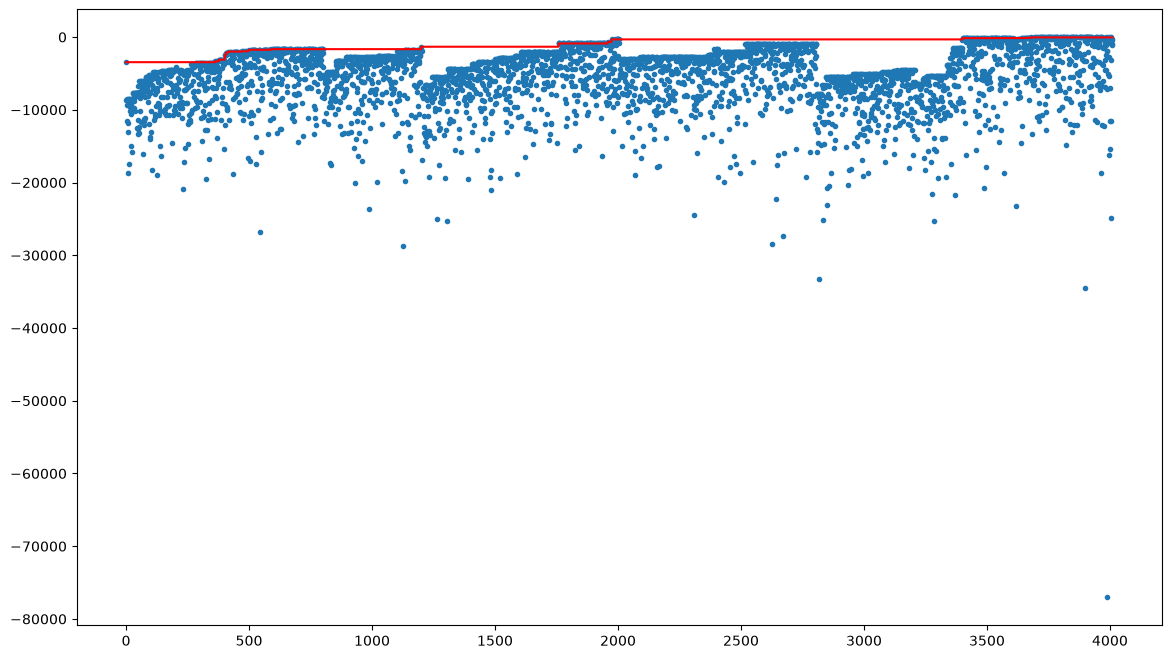

In [70]:
plt.figure(figsize=(14, 8))
plt.plot(
    range(len(set_history)),
    list(accumulate(set_history, max)),
    color="red",
)
_ = plt.scatter(range(len(set_history)), set_history, marker=".")